**Nama** : Shinta Nuraini

**NPM** : 25083010021

**Kelas** : Analisis Numerik/ A083

# **Perhitungan Volume Kedua Lambung Perahu**

##**Tugas**
- Hitung volume kedua lambung kapal.
- Satu dash-kosong adalah 5+5 cm.
- Anggap lantai kapal adalah datar (tidak ada keel) sehingga tampak depan
semuanya persegi panjang.
- Volume reserve buoyancy tidak usah dihitung.

##**Skala**
Satu sisi kotak grid terdiri dari 5 dash + kosong, yaitu 5 x (5 + 5) cm = **50 cm**.


## **1. Input Data dan Skala**
Ukuran lambung (dalam kotak) dimasukkan, lalu dikonversi ke cm dengan skala 1 kotak = 10 cm.

In [2]:
import numpy as np

# Kompatibel dengan NumPy lama (trapz) maupun baru (trapezoid)
trapesium = getattr(np, "trapezoid", None) or np.trapz

# ======================= SKALA =======================
CM_PER_KOTAK = 10.0     # 1 kotak grid = 1 dash + kosong = 5 + 5 cm

# ================= INPUT (satuan: KOTAK) =================
# Hasil pembacaan gambar tiap 1 kotak, dihitung dari ujung kiri lambung (x = 0)
x_kotak = np.array([
    0.0, 1, 2, 3, 4, 5, 6, 7,
    8, 9, 10, 11, 12, 13, 14, 15,
    16, 17, 18, 19, 20, 21, 21.05
])
# Lebar satu lambung dari tampak atas
lebar_kotak = np.array([
    1.076, 1.463, 1.678, 1.893, 2.023, 2.066, 2.152, 2.152,
    2.152, 2.152, 2.152, 2.152, 2.152, 2.152, 2.109, 2.034,
    1.936, 1.721, 1.463, 1.119, 0.646, 0.086, 0.0
])
# Tinggi satu lambung dari tampak samping (dek sampai dasar)
tinggi_kotak = np.array([
    0.796, 1.291, 1.764, 2.173, 2.474, 2.646, 2.646, 2.646,
    2.646, 2.646, 2.646, 2.646, 2.625, 2.625, 2.625, 2.625,
    2.625, 2.625, 2.625, 2.321, 1.377, 0.215, 0.0
])
# Batas lambung utama = posisi sekat reserve buoyancy
X_AWAL_KOTAK = 2.30     # sekat kiri  (garis lengkung dekat buritan)
X_AKHIR_KOTAK = 18.43   # sekat kanan (garis lurus dekat haluan)
JUMLAH_LAMBUNG = 2      # kedua lambung dianggap identik

# ============== KONVERSI KE CM (kotak x 10 cm) ==============
x = x_kotak * CM_PER_KOTAK
lebar = lebar_kotak * CM_PER_KOTAK
tinggi = tinggi_kotak * CM_PER_KOTAK
X_AWAL = X_AWAL_KOTAK * CM_PER_KOTAK
X_AKHIR = X_AKHIR_KOTAK * CM_PER_KOTAK

## **2. Perhitungan Volume**
Langkah 1 sampai 4: luas penampang, volume tiap segmen, pengecekan, lalu konversi satuan dan jumlah kedua lambung.

In [3]:
def lebar_di(posisi):
    return float(np.interp(posisi, x, lebar))


def tinggi_di(posisi):
    return float(np.interp(posisi, x, tinggi))


def luas_di(posisi):
    return lebar_di(posisi) * tinggi_di(posisi)


def garis(ch="-", n=72):
    print(ch * n)


def main():
    # ---------------- LANGKAH 1 ----------------
    # Titik batas segmen: sekat kiri, semua titik data di antaranya, sekat kanan
    batas = [X_AWAL] + [float(t) for t in x if X_AWAL < t < X_AKHIR] + [X_AKHIR]

    garis("=")
    print("LANGKAH 1 - LUAS PENAMPANG DI SETIAP TITIK  (A = lebar x tinggi)")
    garis("=")
    print(f"{'x (cm)':>8}{'Lebar (cm)':>14}{'Tinggi (cm)':>14}{'Luas (cm²)':>16}")
    for t in batas:
        print(f"{t:>8.1f}{lebar_di(t):>14.2f}{tinggi_di(t):>14.2f}{luas_di(t):>16,.2f}")

    # ---------------- LANGKAH 2 ----------------
    print()
    garis("=")
    print("LANGKAH 2 - VOLUME TIAP SEGMEN")
    print("Rumus: V = L/6 x (A_awal + 4 x A_tengah + A_akhir)")
    garis("=")
    print(f"{'Seg':>4}{'x awal':>9}{'x akhir':>9}{'L':>7}"
          f"{'A_awal':>11}{'A_tengah':>11}{'A_akhir':>11}{'V (cm³)':>14}")

    total_cm3 = 0.0
    for i in range(len(batas) - 1):
        x1, x2 = batas[i], batas[i + 1]
        L = x2 - x1
        a1, am, a2 = luas_di(x1), luas_di((x1 + x2) / 2), luas_di(x2)
        v = L / 6 * (a1 + 4 * am + a2)
        total_cm3 += v
        print(f"{i + 1:>4}{x1:>9.1f}{x2:>9.1f}{L:>7.1f}"
              f"{a1:>11,.1f}{am:>11,.1f}{a2:>11,.1f}{v:>14,.1f}")
    garis()
    print(f"{'JUMLAH':>27}{'':>36}{total_cm3:>14,.1f}")

    # ---------------- LANGKAH 3 ----------------
    # Pembanding: irisan tiap 0,1 cm + aturan trapesium
    xs = np.linspace(X_AWAL, X_AKHIR, int(round((X_AKHIR - X_AWAL) / 0.1)) + 1)
    luas_i = np.interp(xs, x, lebar) * np.interp(xs, x, tinggi)
    cek_cm3 = trapesium(luas_i, xs)

    print()
    garis("=")
    print("LANGKAH 3 - PENGECEKAN (irisan 0,1 cm + aturan trapesium)")
    garis("=")
    print(f"Metode segmen (prismatoid) = {total_cm3:,.2f} cm³")
    print(f"Metode irisan 0,1 cm       = {cek_cm3:,.2f} cm³")
    print(f"Selisih                    = {abs(total_cm3 - cek_cm3):,.2f} cm³"
          f" ({abs(total_cm3 - cek_cm3) / total_cm3 * 100:.4f}%)")

    # ---------------- LANGKAH 4 ----------------
    satu_cm3 = total_cm3
    satu_m3 = satu_cm3 / 1_000_000          # 1 m³ = 1.000.000 cm³
    dua_m3 = satu_m3 * JUMLAH_LAMBUNG
    dua_liter = dua_m3 * 1000               # 1 m³ = 1000 liter

    print()
    garis("=")
    print("LANGKAH 4 - KONVERSI SATUAN & JUMLAH KEDUA LAMBUNG")
    garis("=")
    print(f"Satu lambung  : {satu_cm3:,.2f} cm³ / 1.000.000 = {satu_m3:.6f} m³")
    print(f"Kedua lambung : {satu_m3:.6f} m³ x {JUMLAH_LAMBUNG} = {dua_m3:.6f} m³")
    print(f"Dalam liter   : {dua_m3:.6f} m³ x 1000 = {dua_liter:.2f} liter")

    # ---------------- HASIL AKHIR ----------------
    print()
    print("===================================")
    print("HASIL PERHITUNGAN")
    print("===================================")
    print(f"Panjang lambung utama = {X_AKHIR - X_AWAL:.1f} cm")
    print(f"Volume satu lambung  = {satu_cm3:.2f} cm³")
    print(f"Volume satu lambung  = {satu_m3:.6f} m³")
    print(f"Volume kedua lambung = {dua_m3:.6f} m³")
    print(f"Volume kedua lambung = {dua_liter:.2f} liter")


main()

LANGKAH 1 - LUAS PENAMPANG DI SETIAP TITIK  (A = lebar x tinggi)
  x (cm)    Lebar (cm)   Tinggi (cm)      Luas (cm²)
    23.0         17.43         18.87          328.76
    30.0         18.93         21.73          411.35
    40.0         20.23         24.74          500.49
    50.0         20.66         26.46          546.66
    60.0         21.52         26.46          569.42
    70.0         21.52         26.46          569.42
    80.0         21.52         26.46          569.42
    90.0         21.52         26.46          569.42
   100.0         21.52         26.46          569.42
   110.0         21.52         26.46          569.42
   120.0         21.52         26.25          564.90
   130.0         21.52         26.25          564.90
   140.0         21.09         26.25          553.61
   150.0         20.34         26.25          533.92
   160.0         19.36         26.25          508.20
   170.0         17.21         26.25          451.76
   180.0         14.63         26.

## **3. Visualisasi**
Dibuat setelah perhitungan selesai. Grafik atas menunjukkan bentuk lambung dari atas, grafik tengah tampak samping, dan grafik bawah luas penampang A(x). Bagian berwarna adalah lambung utama yang dihitung, bagian abu-abu adalah reserve buoyancy yang tidak dihitung, garis merah putus-putus adalah sekat, dan titik merah adalah data ukur. Luas di bawah kurva A(x) pada bagian berwarna sama dengan volume satu lambung.

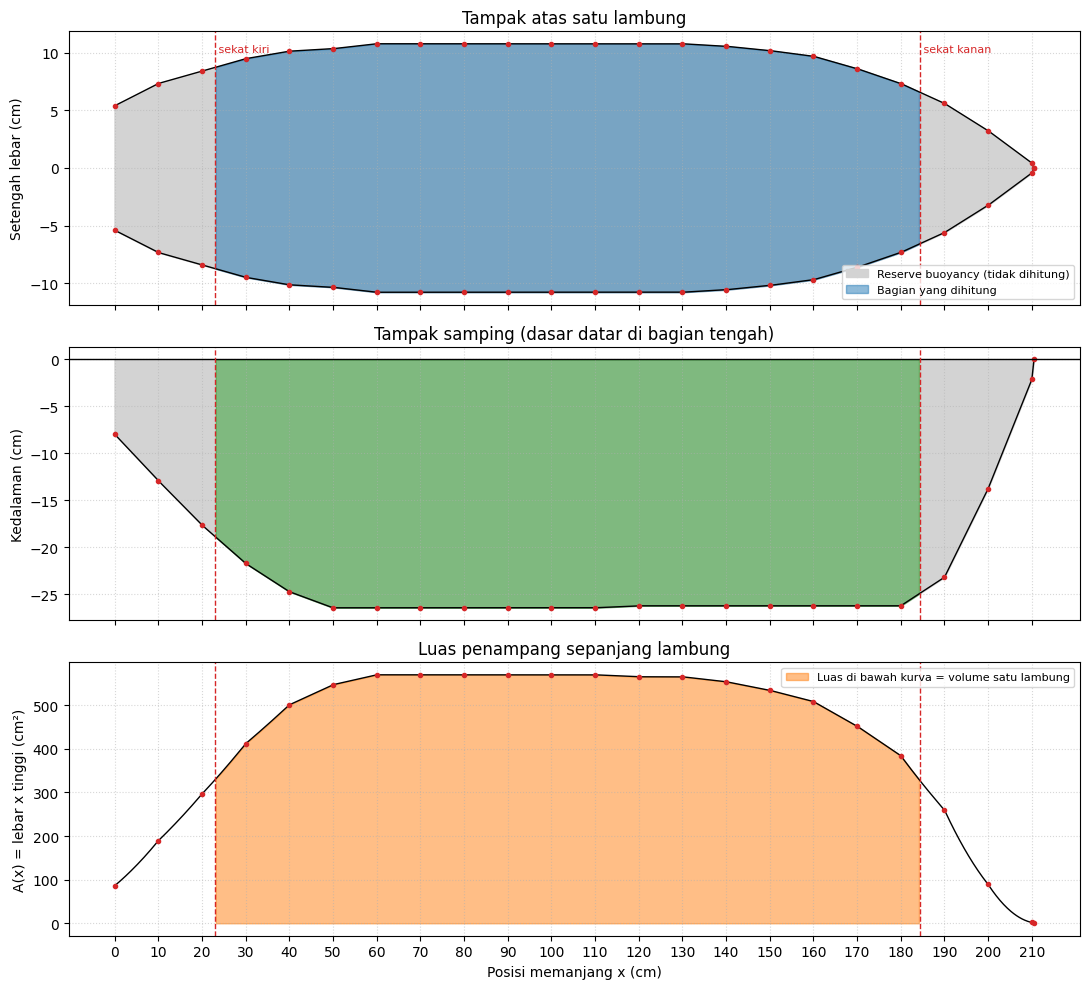

In [4]:
import matplotlib.pyplot as plt


def visualisasi():
    """Tampak atas, tampak samping, dan kurva luas penampang A(x)."""
    xd = np.linspace(0, x[-1], 1000)             # sumbu x halus untuk gambar
    wd = np.interp(xd, x, lebar)
    hd = np.interp(xd, x, tinggi)
    ad = wd * hd
    dalam = (xd >= X_AWAL) & (xd <= X_AKHIR)     # bagian yang dihitung

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

    # ---- Tampak atas ----
    ax1.fill_between(xd, -wd / 2, wd / 2, color="lightgray", label="Reserve buoyancy (tidak dihitung)")
    ax1.fill_between(xd, -wd / 2, wd / 2, where=dalam, color="tab:blue", alpha=0.5,
                     label="Bagian yang dihitung")
    ax1.plot(xd, wd / 2, color="k", lw=1)
    ax1.plot(xd, -wd / 2, color="k", lw=1)
    ax1.plot(x, lebar / 2, "o", color="tab:red", ms=3)
    ax1.plot(x, -lebar / 2, "o", color="tab:red", ms=3)
    ax1.set_ylabel("Setengah lebar (cm)")
    ax1.set_title("Tampak atas satu lambung")
    ax1.legend(loc="lower right", fontsize=8)

    # ---- Tampak samping ----
    ax2.fill_between(xd, 0, -hd, color="lightgray")
    ax2.fill_between(xd, 0, -hd, where=dalam, color="tab:green", alpha=0.5)
    ax2.plot(xd, -hd, color="k", lw=1)
    ax2.plot(x, -tinggi, "o", color="tab:red", ms=3)
    ax2.axhline(0, color="k", lw=1)
    ax2.set_ylabel("Kedalaman (cm)")
    ax2.set_title("Tampak samping (dasar datar di bagian tengah)")

    # ---- Luas penampang A(x) ----
    ax3.plot(xd, ad, color="k", lw=1)
    ax3.fill_between(xd, 0, ad, where=dalam, color="tab:orange", alpha=0.5,
                     label="Luas di bawah kurva = volume satu lambung")
    ax3.plot(x, lebar * tinggi, "o", color="tab:red", ms=3)
    ax3.set_ylabel("A(x) = lebar x tinggi (cm²)")
    ax3.set_xlabel("Posisi memanjang x (cm)")
    ax3.set_title("Luas penampang sepanjang lambung")
    ax3.legend(loc="upper right", fontsize=8)

    # ---- Garis sekat & grid kotak (tiap 10 cm) pada semua grafik ----
    for ax in (ax1, ax2, ax3):
        ax.axvline(X_AWAL, color="tab:red", ls="--", lw=1)
        ax.axvline(X_AKHIR, color="tab:red", ls="--", lw=1)
        ax.set_xticks(np.arange(0, x[-1] + 1, CM_PER_KOTAK))
        ax.grid(True, ls=":", alpha=0.5)
    ax1.text(X_AWAL, ax1.get_ylim()[1] * 0.85, " sekat kiri", color="tab:red", fontsize=8)
    ax1.text(X_AKHIR, ax1.get_ylim()[1] * 0.85, " sekat kanan", color="tab:red", fontsize=8)

    fig.tight_layout()
    plt.show()


visualisasi()

## **Kesimpulan**

Dengan skala 1 kotak grid = 1 dash + kosong = 5 + 5 cm = 10 cm, lambung utama tanpa reserve buoyancy memiliki panjang sekitar 161,3 cm, lebar maksimum sekitar 21,5 cm, dan tinggi sekitar 26,5 cm.

- Volume **satu lambung** sekitar **84.493,75 cm³ = 0,084494 m³**.
- Volume **kedua lambung** sekitar **0,168987 m³ = 168,99 liter**.

Dari perhitungan volume kedua lambung kapal dengan integrasi numerik, metode Simpson 1/3 per segmen memberikan hasil sebesar 0,168987 m³ atau sekitar 168,99 liter. Metode Trapesium dengan irisan 0,1 cm memberikan hasil yang hampir sama, yaitu 0,168987 m³ atau sekitar 168,99 liter. Selisih kedua metode sangat kecil, yaitu sekitar 0,000000005 m³ atau 0,000005 liter (sekitar 0,000003%), sehingga perhitungannya konsisten pada data yang digunakan.

Angka akhir tetap bergantung pada ketelitian pembacaan gambar, skala 1 kotak = 10 cm, serta anggapan bahwa kedua lambung identik, lantai datar, dan sekat kiri berada di posisi rata-rata lengkungannya.

Jadi, volume total kedua lambung kapal dari perhitungan ini adalah sekitar **0,169 m³ atau 168,99 liter**, berdasarkan metode Simpson 1/3.